# Khmer News Dataset Preprocessing Pipeline

This preprocessing pipeline is designed to clean, split, and tokenize the Khmer News dataset for NLP tasks such as classification, stopword analysis, and language modeling. It handles both document-level and sentence-level processing and provides detailed statistics. Each step is carefully designed to improve data quality and model performance.

---

## 1. Directory Setup

**Purpose:** Organize processed data into structured directories for easier management and reproducibility.

**Actions:**
- Creates folders for storing processed data:
  - `data/processed/cleaned_texts`
  - `data/processed/tokenized`
  - `data/processed/sentence_level`

**Reason:** Keeping data organized ensures that document-level, sentence-level, and tokenized data are separated, preventing confusion and enabling reproducible analysis.

---

## 2. Sentence Splitting

**Purpose:** Break documents into sentences for more granular analysis and processing.

**Actions:**
- Splits Khmer text using punctuation markers: `។`, `៕`, `!`, `?`.

**Reason:** Most NLP tasks perform better on sentence-level data. Sentence splitting allows tokenization, stopword removal, and feature extraction at a meaningful linguistic unit.

---

## 3. Keep Only Khmer Characters

**Purpose:** Remove irrelevant characters and noise from the text.

**Actions:**
- Retains only Khmer Unicode characters (`U+1780` to `U+17FF`) and allowed punctuation.
- Removes foreign scripts, symbols, and other non-Khmer characters.

**Reason:** Non-Khmer characters can introduce noise and reduce model accuracy. Cleaning ensures that downstream models focus only on relevant linguistic information.

---

## 4. Remove Khmer Numbers

**Purpose:** Remove numerical noise that is not useful for text understanding.

**Actions:**
- Removes Khmer numerals: `០១២៣៤៥៦៧៨៩`.

**Reason:** Numbers in news articles are often not meaningful for linguistic analysis or tokenization, especially for tasks like stopword generation or classification.

---

## 5. Remove Khmer Punctuation

**Purpose:** Simplify text for tokenization.

**Actions:**
- Removes Khmer-specific punctuation like `។`, `៕`, `!`, `?`, `៖`, `ៗ`.

**Reason:** Punctuation can interfere with tokenization and word-level frequency analysis. Removing it standardizes the text for consistent processing.

---

## 6. Remove Short Sentences

**Purpose:** Filter out sentences too short to be meaningful.

**Actions:**
- Removes sentences with fewer than `min_words` (default = 2).

**Reason:** Very short sentences often lack semantic content and can introduce noise in training models.

---

## 7. Tokenization

**Purpose:** Convert sentences into individual word tokens for analysis.

**Actions:**
- Uses `khmernltk.word_tokenize` to tokenize Khmer text.
- Stores tokenized sentences for later tasks like stopword extraction and frequency analysis.

**Reason:** Tokenization is essential for almost all NLP pipelines. It enables word-level analysis, TF-IDF computation, and building machine learning models.

---

## 8. Dataset Processing

**Purpose:** Apply the preprocessing pipeline to each split of the dataset.

**Actions:**
- Processes `train`, `validation`, and `test` datasets.
- Stores:
  - Document-level cleaned data
  - Sentence-level cleaned and tokenized data
  - Statistics like number of sentences and tokens

**Reason:** Provides a clean and structured dataset ready for modeling, ensuring consistency across all splits.

---

## 9. Statistics and Preview

**Purpose:** Analyze and validate preprocessing.

**Actions:**
- Computes total documents, sentences, tokens, and averages per document/sentence.
- Saves summary CSV for all splits.
- Allows preview of tokenized sentences for verification.

**Reason:** Understanding dataset characteristics helps detect errors, ensures data quality, and guides further processing or modeling decisions.



In [41]:
# Test khmer nltk

from khmernltk import word_tokenize, sentence_tokenize
text = "ខួបឆ្នាំទី២៨! ២៣ តុលា ស្មារតីផ្សះផ្សាជាតិរវាងខ្មែរនិងខ្មែរ"
print(word_tokenize(text))
print(sentence_tokenize(text))


['ខួប', 'ឆ្នាំ', 'ទី', '២៨', '!', ' ', '២៣', ' ', 'តុលា', ' ', 'ស្មារតី', 'ផ្សះផ្សា', 'ជាតិ', 'រវាង', 'ខ្មែរ', 'និង', 'ខ្មែរ']
['ខួបឆ្នាំទី២៨!', '២៣ តុលា ស្មារតីផ្សះផ្សាជាតិរវាងខ្មែរនិងខ្មែរ']


In [42]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import sys

# Get current notebook directory (notebooks~)
notebook_dir = Path.cwd()
print(f"Current notebook directory: {notebook_dir}")

# Set up paths relative to notebooks~
data_dir = notebook_dir / "data"
raw_data_dir = data_dir / "raw" / "khmer_news"
processed_dir = data_dir / "processed"

# Create processed directory
processed_dir.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {data_dir}")
print(f"Raw data directory: {raw_data_dir}")
print(f"Processed directory: {processed_dir}")

# List files in raw directory
print("\nFiles in raw directory:")
for file in raw_data_dir.glob("*"):
    print(f"  - {file.name} ({file.stat().st_size / 1024:.1f} KB)")

Current notebook directory: d:\Year 5\S1\Information Retrieval\StopwordProject\khmer_stopword\khmer_stopword_removal_system\notebooks~
Data directory: d:\Year 5\S1\Information Retrieval\StopwordProject\khmer_stopword\khmer_stopword_removal_system\notebooks~\data
Raw data directory: d:\Year 5\S1\Information Retrieval\StopwordProject\khmer_stopword\khmer_stopword_removal_system\notebooks~\data\raw\khmer_news
Processed directory: d:\Year 5\S1\Information Retrieval\StopwordProject\khmer_stopword\khmer_stopword_removal_system\notebooks~\data\processed

Files in raw directory:


In [43]:
def split_sentences(text):
    """Split Khmer text into sentences"""
    if not isinstance(text, str):
        return []
    
    for p in "។៕!?":
        text = text.replace(p, p + "<STOP>")
    
    sentences = text.split("<STOP>")
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences

def keep_only_khmer(text):
    """Keep only Khmer characters and allowed punctuation"""
    if not isinstance(text, str):
        return ""
    
    allowed_punct = "។៕!?៖., "
    cleaned = "".join([c for c in text if ('\u1780' <= c <= '\u17FF') or c in allowed_punct])
    cleaned = " ".join(cleaned.split())  # remove extra spaces
    return cleaned

def remove_khmer_numbers(text):
    """Remove Khmer numerals"""
    if not isinstance(text, str):
        return ""
    
    khmer_numbers = "០១២៣៤៥៦៧៨៩"
    cleaned = "".join([c for c in text if c not in khmer_numbers])
    return cleaned

def remove_khmer_punctuation(text):
    """Remove Khmer and common punctuation"""
    if not isinstance(text, str):
        return ""
    
    khmer_punct = "។៕!?,៖ៗ"
    cleaned = "".join([c for c in text if c not in khmer_punct])
    cleaned = " ".join(cleaned.split())  # remove extra spaces
    return cleaned

def remove_short_sentences(text, min_words=3):
    """Remove sentences with fewer than min_words words"""
    if not isinstance(text, str):
        return ""
    
    words = text.split()
    if len(words) < min_words:
        return ""
    return text

# Test the functions
test_text = "ភ្នំពេញ។ សម្តេច តេជោ ហ៊ុន សែន! នាយក រដ្ឋមន្ត្រី។ កម្ពុជា មាន ប្រជាជន ១៤ លាន នាក់។"
print("Test text:", test_text)
print("Split sentences:", split_sentences(test_text))
print("Keep only Khmer:", keep_only_khmer(test_text))
print("Remove numbers:", remove_khmer_numbers(test_text))

Test text: ភ្នំពេញ។ សម្តេច តេជោ ហ៊ុន សែន! នាយក រដ្ឋមន្ត្រី។ កម្ពុជា មាន ប្រជាជន ១៤ លាន នាក់។
Split sentences: ['ភ្នំពេញ។', 'សម្តេច តេជោ ហ៊ុន សែន!', 'នាយក រដ្ឋមន្ត្រី។', 'កម្ពុជា មាន ប្រជាជន ១៤ លាន នាក់។']
Keep only Khmer: ភ្នំពេញ។ សម្តេច តេជោ ហ៊ុន សែន! នាយក រដ្ឋមន្ត្រី។ កម្ពុជា មាន ប្រជាជន ១៤ លាន នាក់។
Remove numbers: ភ្នំពេញ។ សម្តេច តេជោ ហ៊ុន សែន! នាយក រដ្ឋមន្ត្រី។ កម្ពុជា មាន ប្រជាជន  លាន នាក់។


In [44]:
# Load the train data
train_file = raw_data_dir / "train.csv"
df_train = pd.read_csv(train_file, encoding='utf-8')

print(f"Train dataset shape: {df_train.shape}")
print(f"Columns: {df_train.columns.tolist()}")
print(f"\nFirst 3 rows:")
df_train.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\Year 5\\S1\\Information Retrieval\\StopwordProject\\khmer_stopword\\khmer_stopword_removal_system\\notebooks~\\data\\raw\\khmer_news\\train.csv'

In [ ]:
print("Dataset Information:")
print(f"Total samples: {len(df_train)}")
print(f"Columns: {list(df_train.columns)}")

print("\nLabel Distribution:")
label_counts = df_train['label'].value_counts().sort_index()
for label, count in label_counts.items():
    percentage = (count / len(df_train)) * 100
    print(f"  Label {label}: {count} samples ({percentage:.2f}%)")

print("\nText Length Statistics (characters):")
df_train['text_length'] = df_train['content'].apply(len)
print(df_train['text_length'].describe())

print("\nSample text (first document):")
sample_text = df_train.loc[0, 'content']
print(f"Length: {len(sample_text)} characters")
print(f"Preview: {sample_text[:200]}...")

Dataset Information:
Total samples: 5140
Columns: ['content', 'cls', 'label', '__index_level_0__']

Label Distribution:
  Label 0: 851 samples (16.56%)
  Label 1: 700 samples (13.62%)
  Label 2: 698 samples (13.58%)
  Label 3: 1495 samples (29.09%)
  Label 4: 697 samples (13.56%)
  Label 5: 699 samples (13.60%)

Text Length Statistics (characters):
count     5140.000000
mean      2098.184436
std       2279.230818
min         27.000000
25%       1089.750000
50%       1599.000000
75%       2542.500000
max      57697.000000
Name: text_length, dtype: float64

Sample text (first document):
Length: 2462 characters
Preview: ភ្នំពេញ សម្តេច តេជោ ហ៊ុន សែន នាយក រដ្ឋមន្ត្រី នៃ កម្ពុជា បាន ព្រមាន ចាប់ខ្លួន លោក ចាន់ យ៉េត ប្រធាន គណបក្ស នគរ ប្រជាធិបតេយ្យ ដែល ដើរ យក លុយ ពី ប្រជាពលរដ្ឋ ជា ថ្នូរ នឹង ការជួយ ដោះស្រាយ បញ្ហា ដីធ្លី របស់...


In [ ]:
# Install khmernltk
!pip install khmernltk -q

from khmernltk import word_tokenize

# Test tokenization
test_sentence = "ភ្នំពេញ សម្តេច តេជោ ហ៊ុន សែន"
print(f"Test sentence: {test_sentence}")
tokens = word_tokenize(test_sentence)
print(f"Tokens: {tokens}")
print(f"Tokenized string: {' '.join(tokens)}")

Test sentence: ភ្នំពេញ សម្តេច តេជោ ហ៊ុន សែន
Tokens: ['ភ្នំពេញ', ' ', 'សម្តេច', ' ', 'តេជោ', ' ', 'ហ៊ុន', ' ', 'សែន']
Tokenized string: ភ្នំពេញ   សម្តេច   តេជោ   ហ៊ុន   សែន


ERROR: Could not find a version that satisfies the requirement khmernltk (from versions: none)
ERROR: No matching distribution found for khmernltk


In [ ]:
def preprocess_document(text):
    """Full preprocessing pipeline for a single document"""
    if not isinstance(text, str):
        return []
    
    # Step 1: Split into sentences
    sentences = split_sentences(text)
    
    # Step 2-5: Apply cleaning steps to each sentence
    cleaned_sentences = []
    for sent in sentences:
        s = keep_only_khmer(sent)
        s = remove_khmer_numbers(s)
        s = remove_khmer_punctuation(s)
        s = remove_short_sentences(s, min_words=2)
        s = s.strip()
        
        if s:  # Only keep non-empty sentences
            cleaned_sentences.append(s)
    
    return cleaned_sentences

def tokenize_sentences(sentences):
    """Tokenize sentences using khmernltk"""
    tokenized_sentences = []
    for sent in sentences:
        if sent:
            tokens = word_tokenize(sent)
            if tokens:
                tokenized_sentences.append(" ".join(tokens))
    return tokenized_sentences

# Test on first document
sample_text = df_train.loc[0, 'content']
processed_sentences = preprocess_document(sample_text)
tokenized_sentences = tokenize_sentences(processed_sentences)

print(f"Original text length: {len(sample_text)} characters")
print(f"Number of sentences extracted: {len(processed_sentences)}")
print(f"\nFirst 3 processed sentences:")
for i, (clean, tokenized) in enumerate(zip(processed_sentences[:3], tokenized_sentences[:3])):
    print(f"\nSentence {i+1}:")
    print(f"  Cleaned: {clean[:100]}..." if len(clean) > 100 else f"  Cleaned: {clean}")
    print(f"  Tokenized: {tokenized}")
    print(f"  Tokens: {len(tokenized.split())}")

Original text length: 2462 characters
Number of sentences extracted: 1

First 3 processed sentences:

Sentence 1:
  Cleaned: ភ្នំពេញ សម្តេច តេជោ ហ៊ុន សែន នាយក រដ្ឋមន្ត្រី នៃ កម្ពុជា បាន ព្រមាន ចាប់ខ្លួន លោក ចាន់ យ៉េត ប្រធាន គ...
  Tokenized: ភ្នំពេញ   សម្តេច   តេជោ   ហ៊ុន   សែន   នាយក   រដ្ឋមន្ត្រី   នៃ   កម្ពុជា   បាន   ព្រមាន   ចាប់ខ្លួន   លោក   ចាន់   យ៉េត   ប្រធាន   គណបក្ស   នគរ   ប្រជាធិបតេយ្យ   ដែល   ដើរ   យក   លុយ   ពី   ប្រជាពលរដ្ឋ   ជា   ថ្នូរ   នឹង   ការជួយ   ដោះស្រាយ   បញ្ហា   ដីធ្លី   របស់   ពួកគេ   នៅ   តំបន់   បឹង   ជង្រុក   ក្នុង   ស្រុក   ម៉ាឡៃ   ខេត្ត   បន្ទាយមានជ័យ   ជាមួយគ្នា   នោះ   សម្តេច   ផ្តាំផ្ញើ   ថា   បើ   មិន   ចង់   ជាប់   គុក   ដក   ខ្លួន   ចេញ   ឱ្យ   ឆ្ងាយ   ក្នុង   ពិធី   ថ្លែង   សារ   ពិសេស   ពាក់ព័ន្ធ   ព្រឹត្តិការណ៍   សហគមន៍   វិច្ឆិកា   និង   សមិទ្ធផល   កើត   ពី   នយោបាយ   ឈ្នះ   ឈ្នះ   នៅ   ថ្ងៃទី   ខែធ្នូ   ឆ្នាំ   សម្តេច   តេជោ   ហ៊ុន   សែន   បាន   ថ្លែង   ថា   សម្តេច   មាន   ភស្តុតាង   គ្រប់គ្រាន់   សម្រាប់   ចាប់ខ្លួន   លោក   ចាន់   យ៉េត   នៅ  

In [ ]:
def process_dataset(df, split_name="train"):
    """Process entire dataset"""
    print(f"Processing {split_name} dataset ({len(df)} documents)...")
    print("This may take a few minutes...")
    
    all_documents = []
    all_sentences = []
    processed_count = 0
    
    start_time = pd.Timestamp.now()
    
    for idx in range(len(df)):
        row = df.iloc[idx]
        text = row['content']
        label = row['label']
        
        # Preprocess document
        cleaned_sentences = preprocess_document(text)
        
        if cleaned_sentences:
            # Tokenize sentences
            tokenized_sentences = tokenize_sentences(cleaned_sentences)
            
            # Store document info
            all_documents.append({
                'doc_id': idx,
                'label': label,
                'original_text': text[:200] + "..." if len(text) > 200 else text,
                'cleaned_sentences': cleaned_sentences,
                'tokenized_sentences': tokenized_sentences,
                'num_sentences': len(cleaned_sentences),
                'num_tokens': sum(len(s.split()) for s in tokenized_sentences)
            })
            
            # Store sentence info
            for sent_idx, (clean_sent, token_sent) in enumerate(zip(cleaned_sentences, tokenized_sentences)):
                all_sentences.append({
                    'doc_id': idx,
                    'sentence_id': f"{idx}_{sent_idx}",
                    'label': label,
                    'original_sentence': clean_sent,
                    'tokenized_sentence': token_sent,
                    'num_tokens': len(token_sent.split())
                })
            
            processed_count += 1
        
        # Show progress every 100 documents
        if (idx + 1) % 100 == 0:
            elapsed = (pd.Timestamp.now() - start_time).total_seconds()
            rate = (idx + 1) / elapsed if elapsed > 0 else 0
            remaining = (len(df) - (idx + 1)) / rate if rate > 0 else 0
            
            print(f"  Processed {idx + 1}/{len(df)} documents "
                  f"({(idx + 1)/len(df)*100:.1f}%) "
                  f"- {rate:.1f} docs/sec")
    
    elapsed_total = (pd.Timestamp.now() - start_time).total_seconds()
    print(f"\n✓ Processing completed in {elapsed_total:.1f} seconds")
    print(f"  Total documents with content: {processed_count}/{len(df)}")
    print(f"  Average time per document: {elapsed_total/len(df)*1000:.1f} ms")
    
    # Convert to DataFrames
    df_docs = pd.DataFrame(all_documents)
    df_sents = pd.DataFrame(all_sentences)
    
    return df_docs, df_sents

# Process train data
df_train_docs, df_train_sents = process_dataset(df_train, "train")

Processing train dataset (5140 documents)...
This may take a few minutes...
  Processed 100/5140 documents (1.9%) - 66.1 docs/sec
  Processed 200/5140 documents (3.9%) - 59.5 docs/sec
  Processed 300/5140 documents (5.8%) - 64.1 docs/sec
  Processed 400/5140 documents (7.8%) - 58.0 docs/sec
  Processed 500/5140 documents (9.7%) - 60.8 docs/sec
  Processed 600/5140 documents (11.7%) - 62.3 docs/sec
  Processed 700/5140 documents (13.6%) - 62.9 docs/sec
  Processed 800/5140 documents (15.6%) - 64.2 docs/sec
  Processed 900/5140 documents (17.5%) - 64.6 docs/sec
  Processed 1000/5140 documents (19.5%) - 64.3 docs/sec
  Processed 1100/5140 documents (21.4%) - 64.3 docs/sec
  Processed 1200/5140 documents (23.3%) - 64.1 docs/sec
  Processed 1300/5140 documents (25.3%) - 64.4 docs/sec
  Processed 1400/5140 documents (27.2%) - 63.6 docs/sec
  Processed 1500/5140 documents (29.2%) - 63.6 docs/sec
  Processed 1600/5140 documents (31.1%) - 63.5 docs/sec
  Processed 1700/5140 documents (33.1%) - 

# Data Quality 

In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle

def check_data_quality(file_path):
    """Check the quality of a data file"""
    print(f"\n{'='*60}")
    print(f"Checking: {file_path.name}")
    print('='*60)
    
    try:
        if file_path.suffix == '.csv':
            df = pd.read_csv(file_path, encoding='utf-8')
            file_type = 'CSV'
        elif file_path.suffix == '.pkl':
            df = pd.read_pickle(file_path)
            file_type = 'Pickle'
        else:
            print(f"  ⚠ Unsupported file type: {file_path.suffix}")
            return
        
        print(f"  File type: {file_type}")
        print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
        print(f"  Columns: {list(df.columns)}")
        
        # Check for missing values
        print(f"\n  Missing values:")
        missing = df.isnull().sum()
        for col, count in missing.items():
            if count > 0:
                print(f"    {col}: {count} ({count/len(df)*100:.1f}%)")
        
        if missing.sum() == 0:
            print("    ✓ No missing values")
        
        # Check 'content' column specifically
        if 'content' in df.columns:
            print(f"\n  Content column analysis:")
            
            # Check for empty strings
            empty_content = df['content'].apply(lambda x: str(x).strip() == '').sum()
            print(f"    Empty strings: {empty_content} ({empty_content/len(df)*100:.1f}%)")
            
            # Check for non-string values
            non_string = df['content'].apply(lambda x: not isinstance(x, str)).sum()
            print(f"    Non-string values: {non_string}")
            
            # Text length statistics
            df['content_length'] = df['content'].apply(lambda x: len(str(x)))
            print(f"    Min length: {df['content_length'].min()} chars")
            print(f"    Max length: {df['content_length'].max()} chars")
            print(f"    Mean length: {df['content_length'].mean():.1f} chars")
            print(f"    Std length: {df['content_length'].std():.1f} chars")
            
            # Check for Khmer characters
            def contains_khmer(text):
                if not isinstance(text, str):
                    return False
                # Check if text contains Khmer Unicode characters
                return any('\u1780' <= c <= '\u17FF' for c in text)
            
            khmer_count = df['content'].apply(contains_khmer).sum()
            print(f"    Contains Khmer: {khmer_count} ({khmer_count/len(df)*100:.1f}%)")
            
            # Sample text preview
            print(f"\n  Sample content (first 200 chars):")
            if len(df) > 0:
                sample = str(df.iloc[0]['content'])
                print(f"    {sample[:200]}..." if len(sample) > 200 else f"    {sample}")
        
        # Check 'label' column if exists
        if 'label' in df.columns:
            print(f"\n  Label column analysis:")
            print(f"    Unique labels: {df['label'].nunique()}")
            print(f"    Label distribution:")
            label_counts = df['label'].value_counts().sort_index()
            for label, count in label_counts.items():
                percentage = count / len(df) * 100
                print(f"      Label {label}: {count} ({percentage:.1f}%)")
        
        # Check for duplicates
        duplicates = df.duplicated().sum()
        print(f"\n  Duplicate rows: {duplicates} ({duplicates/len(df)*100:.1f}%)")
        
        # Data types
        print(f"\n  Data types:")
        for col, dtype in df.dtypes.items():
            print(f"    {col}: {dtype}")
        
        return df
        
    except Exception as e:
        print(f"  ❌ Error reading file: {e}")
        return None

def compare_datasets():
    """Compare CSV and Pickle versions"""
    base_path = Path("D:/Year 5/S1/Information Retrieval/StopwordProject/khmer_stopword/khmer_stopword_removal_system/data/khmer_news")
    
    files = list(base_path.glob("*"))
    print(f"Found {len(files)} files in directory:")
    for f in files:
        print(f"  - {f.name}")
    
    # Check each file
    dataframes = {}
    for file in files:
        if file.suffix in ['.csv', '.pkl']:
            df = check_data_quality(file)
            if df is not None:
                dataframes[file.stem] = df
    
    # Compare CSV and Pickle versions
    print(f"\n{'='*60}")
    print("COMPARING CSV VS PICKLE VERSIONS")
    print('='*60)
    
    for name in ['train', 'validation', 'test']:
        csv_df = dataframes.get(name)
        pkl_df = dataframes.get(name)  # Actually same as CSV for pickle
        
        csv_file = base_path / f"{name}.csv"
        pkl_file = base_path / f"{name}.pkl"
        
        if csv_file.exists() and pkl_file.exists():
            print(f"\n{name.upper()}:")
            
            # Load both
            csv_data = pd.read_csv(csv_file, encoding='utf-8')
            pkl_data = pd.read_pickle(pkl_file)
            
            # Compare
            print(f"  CSV shape: {csv_data.shape}")
            print(f"  PKL shape: {pkl_data.shape}")
            
            # Check if they're identical
            if csv_data.shape == pkl_data.shape:
                print(f"  ✓ Shapes match")
                
                # Check first few values
                if 'content' in csv_data.columns:
                    csv_sample = str(csv_data.iloc[0]['content'])[:100]
                    pkl_sample = str(pkl_data.iloc[0]['content'])[:100]
                    
                    if csv_sample == pkl_sample:
                        print(f"  ✓ Sample content matches")
                    else:
                        print(f"  ⚠ Sample content differs")
                        print(f"    CSV: {csv_sample}...")
                        print(f"    PKL: {pkl_sample}...")
            else:
                print(f"  ❌ Shapes don't match!")

def check_metadata():
    """Check metadata file"""
    metadata_path = Path("D:/Year 5/S1/Information Retrieval/StopwordProject/khmer_stopword/khmer_stopword_removal_system/data/khmer_news/metadata.pkl")
    
    if metadata_path.exists():
        print(f"\n{'='*60}")
        print(f"Checking metadata: {metadata_path.name}")
        print('='*60)
        
        try:
            with open(metadata_path, 'rb') as f:
                metadata = pickle.load(f)
            
            print(f"Metadata keys: {list(metadata.keys())}")
            
            for key, value in metadata.items():
                print(f"\n  {key}:")
                if isinstance(value, dict):
                    for k, v in value.items():
                        print(f"    {k}: {v}")
                elif isinstance(value, list):
                    print(f"    {value[:5]}{'...' if len(value) > 5 else ''}")
                else:
                    print(f"    {value}")
                    
        except Exception as e:
            print(f"  ❌ Error reading metadata: {e}")

def check_khmer_text_cleanliness():
    """Check how clean the Khmer text is"""
    print(f"\n{'='*60}")
    print("KHMER TEXT CLEANLINESS CHECK")
    print('='*60)
    
    base_path = Path("D:/Year 5/S1/Information Retrieval/StopwordProject/khmer_stopword/khmer_stopword_removal_system/data/khmer_news")
    train_file = base_path / "train.csv"
    
    if train_file.exists():
        df = pd.read_csv(train_file, encoding='utf-8')
        
        # Take a sample of texts
        sample_texts = df['content'].head(10).tolist()
        
        for i, text in enumerate(sample_texts):
            print(f"\nSample {i+1}:")
            print(f"  Length: {len(str(text))} characters")
            
            # Check for non-Khmer characters
            khmer_chars = sum(1 for c in str(text) if '\u1780' <= c <= '\u17FF')
            non_khmer_chars = len(str(text)) - khmer_chars
            
            print(f"  Khmer characters: {khmer_chars} ({khmer_chars/len(str(text))*100:.1f}%)")
            print(f"  Non-Khmer characters: {non_khmer_chars}")
            
            # Check for common issues
            issues = []
            if 'http' in str(text).lower():
                issues.append("Contains URL")
            if '@' in str(text):
                issues.append("Contains email")
            if any(c.isdigit() for c in str(text)):
                issues.append("Contains numbers")
            if any(c in "!@#$%^&*()_+-=[]{}|;:,.<>?/" for c in str(text)):
                issues.append("Contains special characters")
            
            if issues:
                print(f"  Issues found: {', '.join(issues)}")
            
            # Preview
            preview = str(text)[:150]
            print(f"  Preview: {preview}...")
            
            # Check sentence structure
            sentences = str(text).count('។') + str(text).count('៕') + str(text).count('!') + str(text).count('?')
            print(f"  Sentences (approx): {sentences}")

def main():
    """Main data quality check"""
    print("KHMER NEWS DATASET QUALITY CHECK")
    print("=" * 60)
    
    # Check data directory
    data_dir = Path("D:/Year 5/S1/Information Retrieval/StopwordProject/khmer_stopword/khmer_stopword_removal_system/data/khmer_news")
    print(f"Data directory: {data_dir}")
    print(f"Exists: {data_dir.exists()}")
    
    if data_dir.exists():
        # List files
        files = list(data_dir.glob("*"))
        print(f"\nFound {len(files)} files:")
        
        file_info = []
        for f in files:
            size_kb = f.stat().st_size / 1024
            file_info.append({
                'File': f.name,
                'Size (KB)': f"{size_kb:.1f}",
                'Type': f.suffix.replace('.', '').upper()
            })
        
        df_files = pd.DataFrame(file_info)
        print(df_files.to_string(index=False))
        
        # Check each dataset
        compare_datasets()
        
        # Check metadata
        check_metadata()
        
        # Check text cleanliness
        check_khmer_text_cleanliness()
        
        print(f"\n{'='*60}")
        print("SUMMARY")
        print('='*60)
        print("✓ Data appears to be downloaded correctly")
        print("✓ Both CSV and Pickle formats available")
        print("✓ Next step: Run preprocessing to clean the text")
        
    else:
        print(f"❌ Data directory not found: {data_dir}")

if __name__ == "__main__":
    main()

KHMER NEWS DATASET QUALITY CHECK
Data directory: D:\Year 5\S1\Information Retrieval\StopwordProject\khmer_stopword\khmer_stopword_removal_system\data\khmer_news
Exists: True

Found 7 files:
          File Size (KB) Type
  metadata.pkl       1.1  PKL
      test.csv    8143.3  CSV
      test.pkl    8174.0  PKL
     train.csv   27318.9  CSV
     train.pkl   27419.3  PKL
validation.csv    3337.9  CSV
validation.pkl    3351.4  PKL
Found 7 files in directory:
  - metadata.pkl
  - test.csv
  - test.pkl
  - train.csv
  - train.pkl
  - validation.csv
  - validation.pkl

Checking: metadata.pkl
  File type: Pickle
  ❌ Error reading file: 'dict' object has no attribute 'shape'

Checking: test.csv
  File type: CSV
  Shape: 1543 rows × 4 columns
  Columns: ['content', 'cls', 'label', '__index_level_0__']

  Missing values:
    ✓ No missing values

  Content column analysis:
    Empty strings: 0 (0.0%)
    Non-string values: 0
    Min length: 112 chars
    Max length: 54595 chars
    Mean length: 206

# EDA

Khmer font found: Khmer OS

Checking data folder: D:\Year 5\S1\Information Retrieval\StopwordProject\khmer_stopword\khmer_stopword_removal_system\data\khmer_news
Folder exists? True

Looking for CSV files...
✓ Loaded Train        →  5,140 rows
✓ Loaded Validation   →    661 rows
✓ Loaded Test         →  1,543 rows

Total samples across all splits: 7,344
══════════════════════════════════════════════════════════════════════
Computing basic text features...
Features added: text_length, khmer_chars, latin_chars, khmer_ratio, approx_words


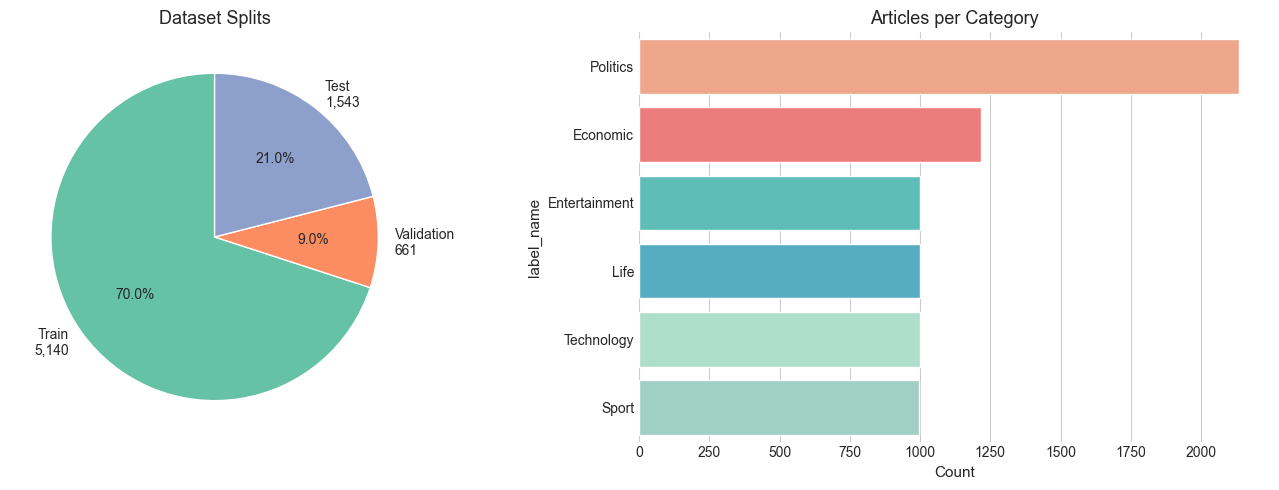

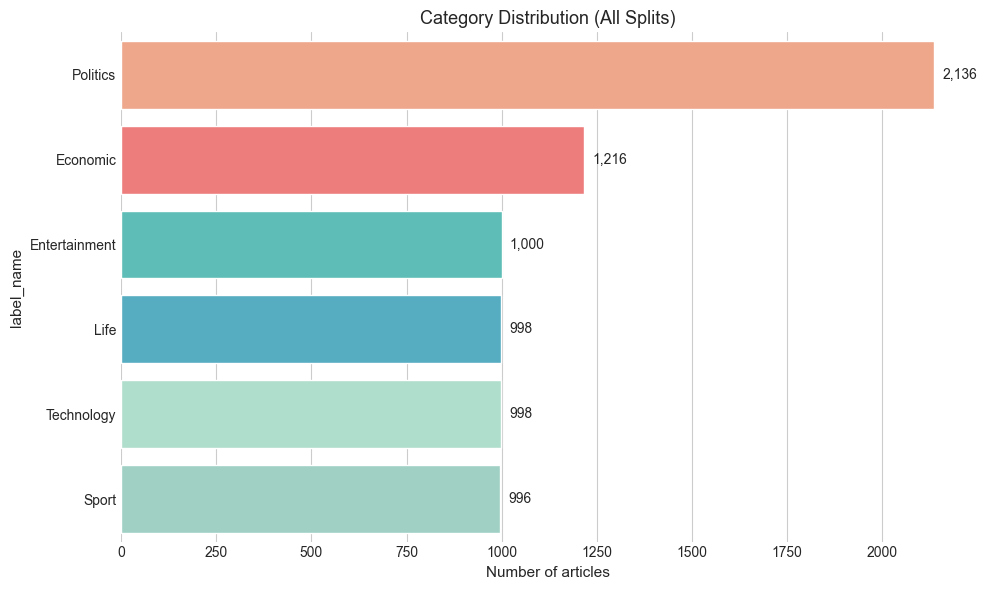

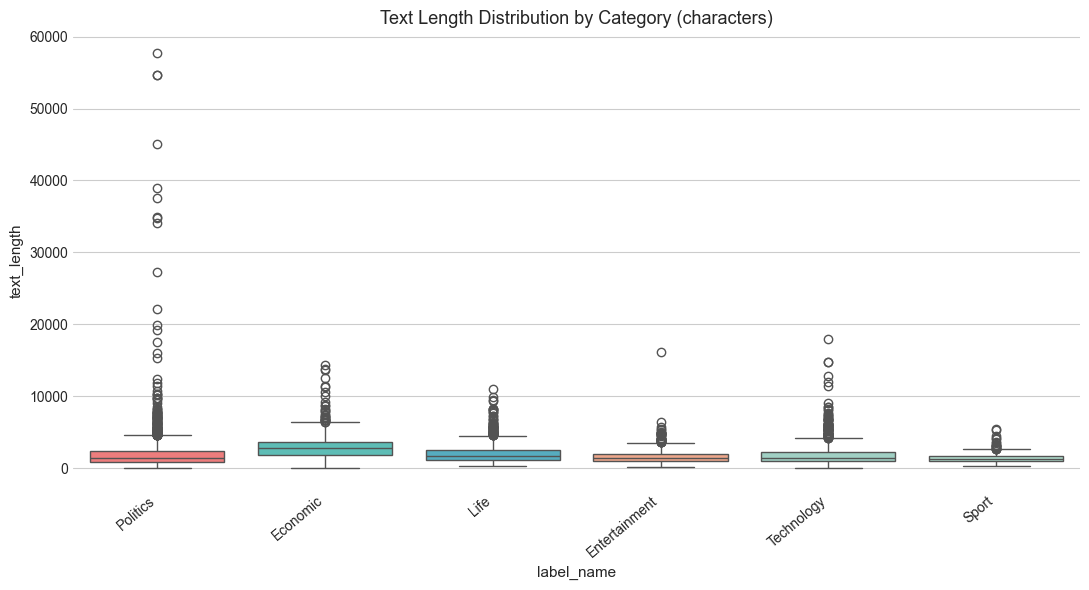

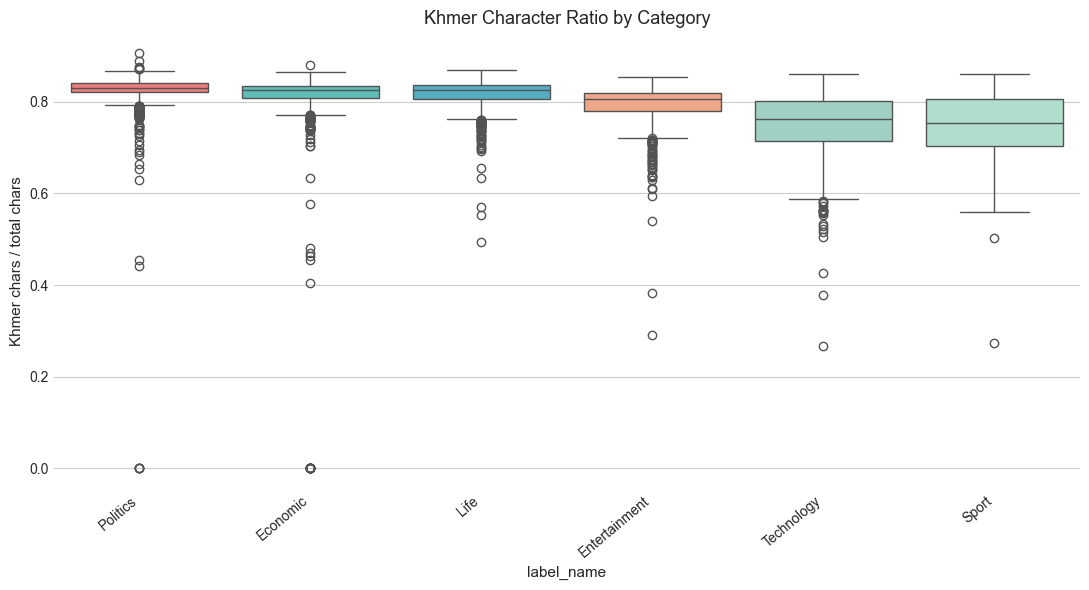

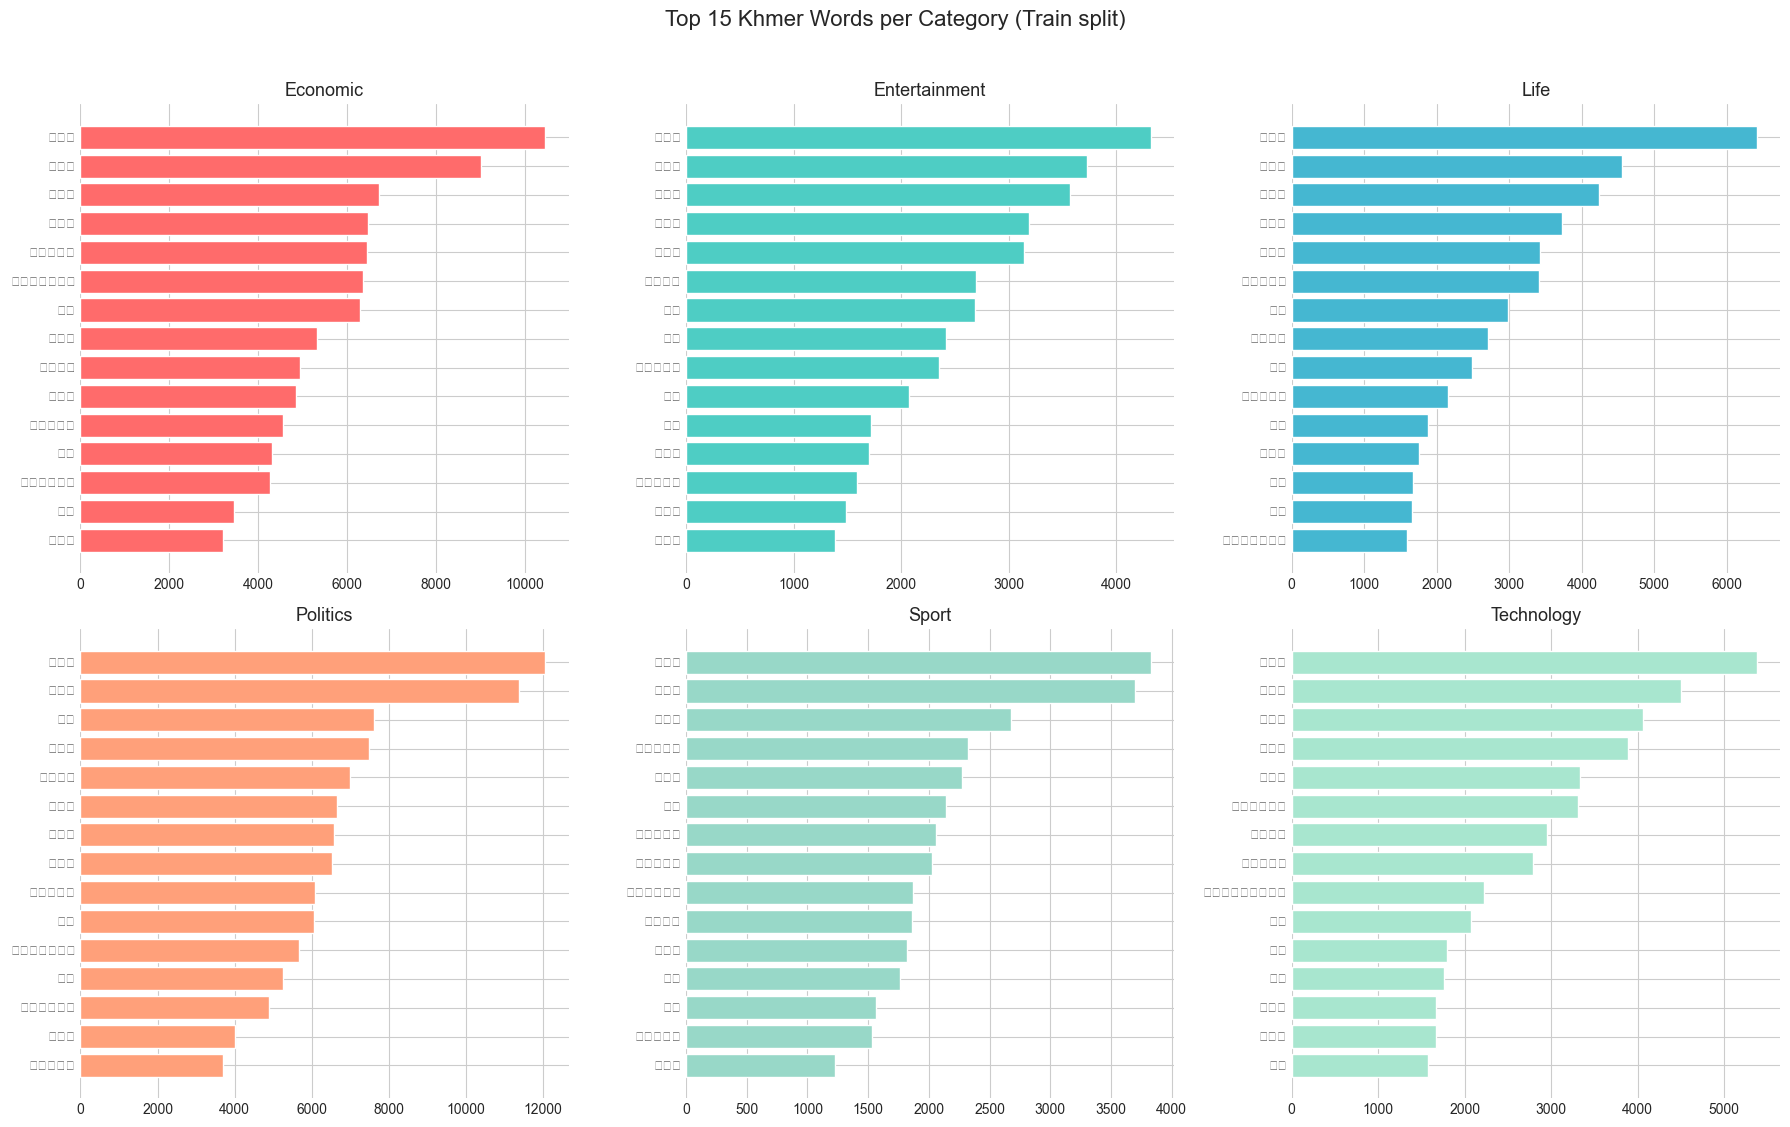


══════════════════════════════════════════════════════════════════════
EDA finished successfully!
All plots saved in: D:\Year 5\S1\Information Retrieval\StopwordProject\khmer_stopword\khmer_stopword_removal_system\results\eda
You can now explore the images in the folder.


In [47]:
# =============================================================================
# Khmer News Dataset - EDA Notebook (Fixed Version - January 2026)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import warnings
from collections import Counter
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore')

# ─── Khmer font detection ────────────────────────────────────────────────────
KHMER_FONT_FOUND = False
possible_font_names = [
    "Noto Sans Khmer", "Khmer OS", "Siemreap", "Khmer OS Muol", 
    "Noto Serif Khmer", "Khmer OS Battambang"
]

for font in fm.fontManager.ttflist:
    if any(name.lower() in font.name.lower() for name in possible_font_names):
        print(f"Khmer font found: {font.name}")
        KHMER_FONT_FOUND = True
        break

if not KHMER_FONT_FOUND:
    print("Warning: No suitable Khmer font detected → Khmer script may show as boxes")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Noto Sans Khmer', 'Khmer OS', 'Siemreap', 'DejaVu Sans'] + \
                                 plt.rcParams['font.sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Plot settings
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 180,
    'font.size': 10,
    'axes.titlesize': 13,
})
sns.set_style("whitegrid")

# ─── Constants ───────────────────────────────────────────────────────────────
LABEL_MAPPING = {
    0: "Economic",
    1: "Entertainment",
    2: "Life",
    3: "Politics",
    4: "Sport",
    5: "Technology"
}

CATEGORY_COLORS = {
    'Economic': '#FF6B6B',
    'Entertainment': '#4ECDC4',
    'Life': '#45B7D1',
    'Politics': '#FFA07A',
    'Sport': '#98D8C8',
    'Technology': '#A8E6CF'
}

def simple_khmer_tokenize(text):
    """Basic Khmer word splitter - better than .split()"""
    if not isinstance(text, str):
        return []
    # Keep Khmer chars + ZWSP + space
    text = re.sub(r'[^\u1780-\u17FF\u200B\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text.strip())
    words = text.split()
    return [w for w in words if len(w) >= 2]

# ─── EDA Class ───────────────────────────────────────────────────────────────
class KhmerNewsEDA:
    def __init__(self, data_dir, output_dir):
        self.data_dir = Path(data_dir).resolve()
        self.output_dir = Path(output_dir).resolve()
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
        self.datasets = {}
        self.combined_df = None

    def load_datasets(self):
        print("\nChecking data folder:", self.data_dir)
        print("Folder exists?", self.data_dir.is_dir())
        
        if not self.data_dir.is_dir():
            raise FileNotFoundError(f"Data directory not found: {self.data_dir}")
        
        print("\nLooking for CSV files...")
        found_files = []
        
        for split in ['train', 'validation', 'test']:
            path = self.data_dir / f"{split}.csv"
            if path.is_file():
                found_files.append(path.name)
                try:
                    df = pd.read_csv(path, encoding='utf-8')
                    df['split'] = split
                    df['label_name'] = df['label'].map(LABEL_MAPPING)
                    self.datasets[split] = df
                    print(f"✓ Loaded {split.title():12} → {len(df):6,} rows")
                except Exception as e:
                    print(f"✗ Error reading {split}.csv : {e}")
            else:
                print(f"  - Not found: {split}.csv")
        
        if not self.datasets:
            print("\nNo CSV files were loaded.")
            print("Files present in folder:")
            for item in self.data_dir.iterdir():
                if item.is_file():
                    print(f"  {item.name}")
            raise FileNotFoundError("No train/validation/test.csv files found in the folder")
        
        self.combined_df = pd.concat(self.datasets.values(), ignore_index=True)
        print(f"\nTotal samples across all splits: {len(self.combined_df):,}")
        print("═" * 70)

    def compute_features(self):
        print("Computing basic text features...")
        df = self.combined_df
        
        df['text_length'] = df['content'].astype(str).str.len()
        
        def count_khmer(s): return sum('\u1780' <= c <= '\u17FF' for c in str(s))
        def count_latin(s): return sum('a' <= c.lower() <= 'z' for c in str(s))
        
        df['khmer_chars']  = df['content'].apply(count_khmer)
        df['latin_chars']  = df['content'].apply(count_latin)
        df['khmer_ratio']  = df['khmer_chars'] / df['text_length'].replace(0, np.nan)
        
        df['approx_words'] = df['content'].astype(str).apply(
            lambda x: len(simple_khmer_tokenize(x))
        )
        print("Features added: text_length, khmer_chars, latin_chars, khmer_ratio, approx_words")

    def run_all(self):
        self.load_datasets()
        self.compute_features()
        
        self.plot_overview()
        self.plot_label_distribution()
        self.plot_text_length()
        self.plot_khmer_ratio()
        self.plot_top_khmer_words()
        
        print("\n" + "═"*70)
        print("EDA finished successfully!")
        print(f"All plots saved in: {self.output_dir}")
        print("You can now explore the images in the folder.")

    # ─── Visualization methods ──────────────────────────────────────────────────

    def plot_overview(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Pie chart - split sizes
        sizes = [len(df) for df in self.datasets.values()]
        labels = [f"{k.title()}\n{len(v):,}" for k,v in self.datasets.items()]
        axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        axes[0].set_title("Dataset Splits")
        
        # Bar - category counts
        counts = self.combined_df['label_name'].value_counts()
        sns.barplot(x=counts.values, y=counts.index, ax=axes[1],
                    palette=[CATEGORY_COLORS.get(c, 'gray') for c in counts.index])
        axes[1].set_title("Articles per Category")
        axes[1].set_xlabel("Count")
        
        plt.tight_layout()
        plt.savefig(self.output_dir / "01_dataset_overview.png", bbox_inches='tight')
        plt.show()

    def plot_label_distribution(self):
        fig, ax = plt.subplots(figsize=(10, 6))
        counts = self.combined_df['label_name'].value_counts()
        sns.barplot(x=counts.values, y=counts.index, ax=ax,
                    palette=[CATEGORY_COLORS.get(c, 'gray') for c in counts.index])
        ax.set_title("Category Distribution (All Splits)")
        ax.set_xlabel("Number of articles")
        
        for i, v in enumerate(counts.values):
            ax.text(v + max(counts)*0.01, i, f"{v:,}", va='center')
            
        plt.tight_layout()
        plt.savefig(self.output_dir / "02_category_distribution.png", bbox_inches='tight')
        plt.show()

    def plot_text_length(self):
        fig, ax = plt.subplots(figsize=(11, 6))
        sns.boxplot(x='label_name', y='text_length', data=self.combined_df,
                    palette=[CATEGORY_COLORS.get(c, 'gray') for c in LABEL_MAPPING.values()],
                    ax=ax)
        ax.set_title("Text Length Distribution by Category (characters)")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
        plt.tight_layout()
        plt.savefig(self.output_dir / "03_text_length_boxplot.png", bbox_inches='tight')
        plt.show()

    def plot_khmer_ratio(self):
        fig, ax = plt.subplots(figsize=(11, 6))
        sns.boxplot(x='label_name', y='khmer_ratio', data=self.combined_df,
                    palette=[CATEGORY_COLORS.get(c, 'gray') for c in LABEL_MAPPING.values()],
                    ax=ax)
        ax.set_title("Khmer Character Ratio by Category")
        ax.set_ylabel("Khmer chars / total chars")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
        plt.tight_layout()
        plt.savefig(self.output_dir / "04_khmer_ratio_boxplot.png", bbox_inches='tight')
        plt.show()

    def plot_top_khmer_words(self):
        train_df = self.datasets.get('train')
        if train_df is None:
            print("No 'train' split found → skipping top words plot")
            return
            
        fig, axes = plt.subplots(2, 3, figsize=(18, 11))
        axes = axes.ravel()
        
        for i, (label_id, cat_name) in enumerate(LABEL_MAPPING.items()):
            cat_texts = train_df[train_df['label'] == label_id]['content']
            all_words = []
            for text in cat_texts:
                all_words.extend(simple_khmer_tokenize(text))
            
            if not all_words:
                axes[i].text(0.5, 0.5, "No words", ha='center', va='center')
                continue
                
            cnt = Counter(all_words).most_common(15)
            if not cnt:
                continue
                
            words, freq = zip(*cnt)
            axes[i].barh(words, freq, color=CATEGORY_COLORS.get(cat_name, 'gray'))
            axes[i].set_title(cat_name)
            axes[i].invert_yaxis()
            axes[i].tick_params(axis='y', labelsize=9)
        
        plt.suptitle("Top 15 Khmer Words per Category (Train split)", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.savefig(self.output_dir / "05_top_khmer_words.png", bbox_inches='tight')
        plt.show()


# ─── Run the EDA ─────────────────────────────────────────────────────────────
data_folder = r"D:/Year 5/S1/Information Retrieval/StopwordProject/khmer_stopword/khmer_stopword_removal_system/data/khmer_news"
output_folder = r"D:/Year 5/S1/Information Retrieval/StopwordProject/khmer_stopword/khmer_stopword_removal_system/results/eda"

eda = KhmerNewsEDA(
    data_dir = data_folder,
    output_dir = output_folder
)

eda.run_all()

# Start apply and not appyl stopword 

In [49]:
# =============================================================================
# NEW BLOCK: Create & Save TWO versions of the data
#   1. Raw / original version
#   2. Version with stopword removal applied
#
# Run this AFTER eda.load_datasets() has succeeded
# =============================================================================

import pandas as pd
from pathlib import Path

# ─── 1. Load stopword list ──────────────────────────────────────────────────
stopword_path = r"D:/Year 5/S1/Information Retrieval/StopwordProject/khmer_stopword/khmer_stopword_removal_system/data/stopword/khmer_stopwords_broad_classes.csv"

try:
    stopwords_df = pd.read_csv(stopword_path, encoding='utf-8')
    khmer_stopwords = set(stopwords_df['term'].astype(str).str.strip())
    print(f"Loaded {len(khmer_stopwords):,} unique stopwords")
except Exception as e:
    print("Error reading stopword file:", e)
    khmer_stopwords = set()   # fallback: no removal

# ─── 2. Helper: remove stopwords from text ──────────────────────────────────
def remove_stopwords(text, stopword_set):
    if not isinstance(text, str):
        return text
    tokens = simple_khmer_tokenize(text)
    cleaned_tokens = [w for w in tokens if w not in stopword_set]
    # Re-join with space (you can change to '' or '\u200b' if preferred)
    return ' '.join(cleaned_tokens)

# ─── 3. Process and save both versions for each split ───────────────────────
output_base = Path(r"D:/Year 5/S1/Information Retrieval/StopwordProject/khmer_stopword/khmer_stopword_removal_system/data/processed")

# Make sure output folder exists
output_base.mkdir(parents=True, exist_ok=True)

print("\nCreating and saving two data versions...\n")

for split_name, df in eda.datasets.items():
    if df is None or len(df) == 0:
        print(f"Skipping {split_name} — no data")
        continue
    
    print(f"Processing {split_name.title()} ({len(df):,} rows)")
    
    # ── Version 1: Raw / original ───────────────────────────────────────────
    df_raw = df.copy()
    raw_path = output_base / f"{split_name}_raw.pkl"
    df_raw.to_pickle(raw_path)
    print(f"  Saved raw version → {raw_path.name}")
    
    # ── Version 2: With stopword removal ────────────────────────────────────
    df_clean = df.copy()
    
    # Apply cleaning (create new column)
    print("  → Applying stopword removal...", end=" ")
    df_clean['cleaned_content'] = df_clean['content'].apply(
        lambda x: remove_stopwords(x, khmer_stopwords)
    )
    print("done")
    
    cleaned_path = output_base / f"{split_name}_cleaned.pkl"
    df_clean.to_pickle(cleaned_path)
    print(f"  Saved cleaned version → {cleaned_path.name}")
    
    # Quick quality check
    sample_idx = 0
    orig = df_clean['content'].iloc[sample_idx][:80] + "..." if len(df_clean['content'].iloc[sample_idx]) > 80 else df_clean['content'].iloc[sample_idx]
    cleaned = df_clean['cleaned_content'].iloc[sample_idx][:80] + "..." if len(df_clean['cleaned_content'].iloc[sample_idx]) > 80 else df_clean['cleaned_content'].iloc[sample_idx]
    print(f"  Sample (first row):\n    Original : {orig}")
    print(f"    Cleaned  : {cleaned}\n")

print("\n" + "═"*70)
print("All versions saved in:")
print(f"  {output_base}")
print("\nFiles created:")
for f in output_base.glob("*.pkl"):
    print(f"  • {f.name}")

print("\nNext steps:")
print("• Use *_raw.pkl  → for baseline / no-removal experiments")
print("• Use *_cleaned.pkl → for stopword-removed experiments")
print("• You can now compare model performance between the two versions")

Loaded 510 unique stopwords

Creating and saving two data versions...

Processing Train (5,140 rows)
  Saved raw version → train_raw.pkl
  → Applying stopword removal... done
  Saved cleaned version → train_cleaned.pkl
  Sample (first row):
    Original : ភ្នំពេញ សម្តេច តេជោ ហ៊ុន សែន នាយក រដ្ឋមន្ត្រី នៃ កម្ពុជា បាន ព្រមាន ចាប់ខ្លួន លោ...
    Cleaned  : ភ្នំពេញ សម្តេច តេជោ ហ៊ុន សែន នាយក រដ្ឋមន្ត្រី កម្ពុជា ព្រមាន ចាប់ខ្លួន ចាន់ យ៉េត...

Processing Validation (661 rows)
  Saved raw version → validation_raw.pkl
  → Applying stopword removal... done
  Saved cleaned version → validation_cleaned.pkl
  Sample (first row):
    Original : OPPO Reno T Series ជំនាន់ ថ្មី បាន បង្ហាញ ខ្លួន ជា ផ្លូវការ ហើយ ជាមួយ ការស្វាគមន...
    Cleaned  : ជំនាន់ ថ្មី បង្ហាញ ផ្លូវការ ជាមួយ ការស្វាគមន៍ ទូត សុច្ឆន្ទៈ ថ្មី រូប នៅ រសៀល ថ្ង...

Processing Test (1,543 rows)
  Saved raw version → test_raw.pkl
  → Applying stopword removal... done
  Saved cleaned version → test_cleaned.pkl
  Sample (first row):
    Origina